# Bead calibration
This is the GFAS glass bead calibration file 

It uses the following datasets: 
- raw PbP data from GFASLabExperiments2024/cal_beads  
- scale factors in PbP_processing/detector_scaling_factors

Sub-routines needed:
- PbP_processing/GFAS101_processing


author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 


Last modified June 26 2026

In [5]:
import sys  
import numpy as np
import pandas as pd
import glob2
import glob, os
import os
from io import BytesIO
import datetime as dt
import calendar
from pandas.errors import EmptyDataError
from scipy.ndimage import shift
import scipy
import metpy
from metpy.calc import wind_components,wind_speed,wind_direction
from metpy.units import units
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors
import shapely 
import matplotlib.ticker as ticker
import matplotlib 
import PyMieScatt  as pms
from scipy.stats import linregress
import dask
import dask.dataframe as dd
from scipy.stats import lognorm
from pathlib import Path

project_dir = Path.cwd().parent
sys.path.append(str(project_dir))
from PbP_processing.GFAS101_processing import *


In [14]:
scale_factors = pd.read_csv('/home/leha7253/instrumentation-GFAS/PbP_processing/detector_scaling_factors', index_col = 0).T

## read in GFAS and correct it

In [15]:
import re
import os
path = '/static/StationData/Campaigns/GFASLabExperiments2024/cal_beads'
filetype = str('GFAS_PbP_Data')
flist = [f for f in glob.glob(path + "/*") if ((f[-5:] == 'Glass')|(f[-7:] == 'Glass 2'))]

flists3=[]
for file in range(len(flist)):
        flist3 = glob.glob(flist[file] + "/*GFAS_PbP_Data*.csv")
        flists3=flists3+flist3

dfs = {}
#print(flists3)
for file in flists3:
        try:
                df = pd.read_csv(file, encoding='latin1')
                df.rename(columns=lambda x: x[0:6] if x.startswith('Bin') else x.strip(), inplace=True)
                df['datetime'] = (pd.to_datetime(dt.datetime(1904, 1, 1)) + 
                                        pd.to_timedelta(df['Computer Time (sec)'].values, 's'))
                # --- extract size ---
                size_match = re.search(r'(\d+\.?\d*)um', file)
                size = int(float(size_match.group(1)))

                # --- detect variant ---
                if 'Glass 2' in file:
                        variant = 'b'
                else:
                        variant = 'a'

                key = f"b{size}_{variant}"
                dfs[key] = df
        except pd.errors.EmptyDataError:
                print(f"No columns to parse from file {file}")
        



In [16]:
# merge 2 glass bead calibration of diameter 5 and delete one of diameter 8 bc the data looked too wonky
keys_to_merge = ['b5_a', 'b5_b']

dfs['b5'] = pd.concat([dfs[k] for k in keys_to_merge], ignore_index=True)

for k in keys_to_merge:
    del dfs[k]
dfs.pop('b8_b')
dfs.keys()

dict_keys(['b30_a', 'b2_a', 'b8_a', 'b15_a', 'b5'])

In [17]:
# apply attenuation correction
for df in dfs:
    dfs[df] = attenuation(dfs[df])
dfs_all = dfs.copy()

In [18]:
# remove noise mode in beads > 5 µm
for key, df in dfs.items():
    if key in  ('b2_a' , 'b5'):
        continue
    if key == 'b30_a':
        dfs[key] = dfs[key][dfs[key]['Sizer Peak'] >= 10000]
    else:
        dfs[key] = dfs[key][dfs[key]['Sizer Peak'] >= 3000]

In [19]:
# put everything in a dict to loop it easier in the next steps
order = ['b2_a', 'b5', 'b8_a', 'b15_a', 'b30_a']
dfs = {k: dfs[k] for k in order if k in dfs}
dfs_all = {k: dfs_all[k] for k in order if k in dfs_all}

dfs.keys()

dict_keys(['b2_a', 'b5', 'b8_a', 'b15_a', 'b30_a'])

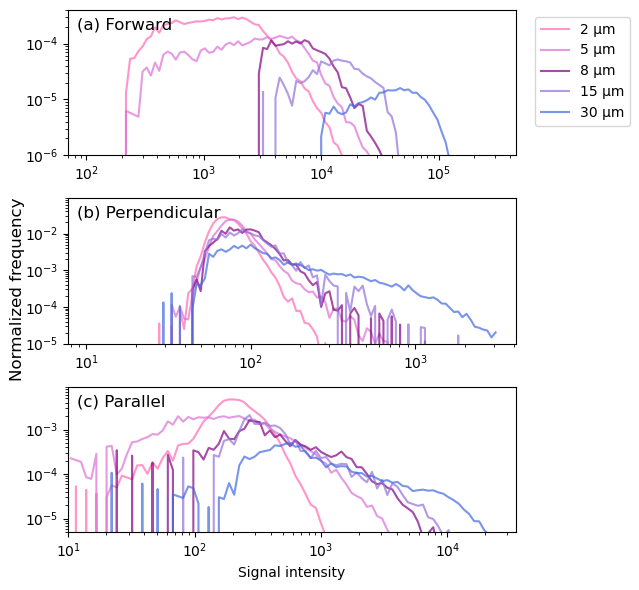

In [20]:
sizer_hist = pd.DataFrame()
P_hist = pd.DataFrame()
S_hist = pd.DataFrame()


for key, df in dfs.items():
    N, value = np.histogram(df['Sizer Peak'], bins = np.logspace(2,5.5,100), density = True)
    midpoint = value[:-1] + np.diff(value)/2
    sizer_hist.index = midpoint
    sizer_hist[key] = N

    N, value = np.histogram(df['P Peak'], bins = np.logspace(1,5,100), density = True)
    midpoint = value[:-1] + np.diff(value)/2
    P_hist.index = midpoint
    P_hist[key] = N

    N, value = np.histogram(df['S Peak'], bins = np.logspace(1,3.5,100), density = True)
    midpoint = value[:-1] + np.diff(value)/2
    S_hist.index = midpoint
    S_hist[key] = N
    
cols = ['hotpink', 'orchid', 'purple', 'mediumpurple', 'royalblue']

fig, ax = plt.subplots(3, figsize = (6.5,6))

for (key, df), c in zip(dfs.items(), cols):
    df = df[df['P Peak']> 0]
    df = df[df['S Peak']> 0]
    '''    ax[0].hist(df['Sizer Peak'], bins=np.logspace(2,5.5,100),
               alpha=0.7, histtype='step', linewidth=1.5,
               label=key, color=c, density = True)

    ax[1].hist(df['S Peak'], bins=np.logspace(1,3.5,100),
               alpha=0.7, histtype='step', linewidth=1.5,
               label=key, color=c, density = True)

    ax[2].hist(df['P Peak'], bins=np.logspace(1,5,100),
               alpha=0.7, histtype='step', linewidth=1.5,
               label=key, color=c, density = True)'''
    ax[0].plot(sizer_hist[key], 
               alpha=0.7, linewidth=1.5,
               label=key, color=c)

    ax[1].plot(S_hist[key], 
               alpha=0.7, linewidth=1.5,
               label=key, color=c)

    ax[2].plot(P_hist[key], 
               alpha=0.7, linewidth=1.5,
               label=key, color=c)

    
ax[0].legend(['2 µm', '5 µm', '8 µm', '15 µm', '30 µm' ],bbox_to_anchor=(1.27, 1))
ax[0].set( xscale ='log', yscale = 'log',ylim=(10**-6,4*10**-4), )
ax[1].set( xscale ='log', yscale = 'log', ylim=(10**-5,9*10**-2), )
ax[2].set(xlabel='Signal intensity', xscale ='log', yscale = 'log',ylim=(5*10**-6,9*10**-3), xlim=(10,35000),)
# have a shared y-axis label
fig.text(0.0, 0.51, 'Normalized frequency', va='center', rotation='vertical', fontsize=12)
# add (a) Sizer etc as text to the top left of each subplot
ax[0].text(0.02, 0.95, '(a) Forward', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.02, 0.95, '(b) Perpendicular', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[2].text(0.02, 0.95, '(c) Parallel', transform=ax[2].transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
#plt.savefig('glassbeads_backscatter.png', dpi=300)

## fit distribution on it 

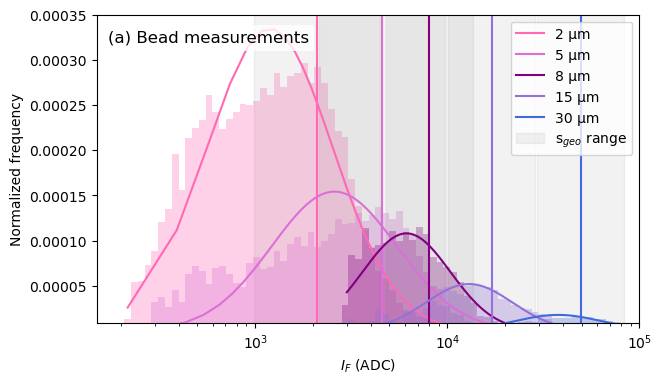

In [21]:
col = 'Sizer Peak'   # change to your column
lab = ['2','5','8','15','30']
modes = []
means = []
gsds = []
geom_means=[]
scale_M =[]
shape_M =[]
farben = ['hotpink', 'orchid', 'purple', 'mediumpurple', 'royalblue']

fig, ax = plt.subplots(figsize=(7,4))

for (key, df), i in zip(dfs.items(), range(len(lab))):
    
    data = df[col].dropna().values
    data = data[data > 0]   # lognormal requires positive values
    
    if len(data) == 0:
        continue

    # --- Fit ---
    shape, loc, scale = lognorm.fit(data, floc=0)
    
    # --- Mode ---
    mode = scale * np.exp(-shape**2)
    modes.append(mode)

    # --- Geometric standard deviation ---
    gsd = np.exp(shape)
    gsds.append(gsd)

    # --- geom_mean ---
    geom_mean = scale
    geom_means.append(geom_mean)

    # --- Mean ---
    mean = scale * np.exp(shape**2 / 2)
    means.append(mean)

    shape_M.append(shape)
    scale_M.append(scale)

    # --- Plot ---
    
    # Histogram
    #ax.hist(dfs_all[key][col], bins=np.logspace(2,5.5,100), density=True, alpha=0.1, label='All data', color = 'grey', )
    ax.hist(data, bins=np.logspace(2,5.5,100), density=True, color = farben[i], alpha=0.3)
    
    # PDF
    x = np.linspace(data.min(), data.max(), 1000)
    pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
    ax.plot(x, pdf, color = farben[i], label = f"{lab[i]} µm")

    ax.axvline(geom_mean, color = farben[i], )#label = f"geometric mean" if i == 4 else None

    # fill between geom_mean/gsd and geom_mean*gsd
    ax.fill_betweenx(y = ax.get_ylim(), x1 = geom_mean/gsd, x2 = geom_mean*gsd, color = 'grey', alpha = 0.1, label = 's$_{geo}$ range' if i == 4 else None)

    # Labels
    ax.set(
        xlabel="$I_{F}$ (ADC)",
        ylabel="Normalized frequency",
        xscale = 'log',
        ylim=(9e-6, ax.get_ylim()[1]*0.99),
        xlim=(150,1e5),
        
    )

ax.text(0.02, 0.95, "(a) Bead measurements", transform=ax.transAxes, ha='left', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.legend(loc='upper right')#bbox_to_anchor=(1.33, 1)
#plt.savefig("lognorm_fit_all.png", bbox_inches='tight')
plt.show()

In [22]:
# all statistics on bead calibration into a dataframe
stats_beads =pd.DataFrame([modes, geom_means, gsds,means, shape_M, scale_M], index = ['mode','geom_mean', 'gsd', 'mean', 'shape', 'scale'], columns = dfs.keys()).T


In [23]:
# natural space stats (not needed; just to check)
measurements_described = []
for key, df in dfs.items():
    b = df['Sizer Peak'].describe()
    measurements_described.append(b)

measurements_described = pd.DataFrame(measurements_described, index = dfs.keys())
measurements_described 


,count,mean,std,min,25%,50%,75%,max
b2_a,17562.0,2837.612902,4172.643579,216.828177,1332.596616,2210.199501,3357.212912,173887.200706
b5,9101.0,5912.222270,4915.559659,212.794165,3085.401056,5019.359938,7217.795351,109315.314701
b8_a,1292.0,9401.688329,6384.302521,3000.000000,5532.827539,7878.276305,11164.867755,74093.893152
b15_a,566.0,19272.919728,9631.047155,3161.453600,12363.891269,17440.515796,25073.798577,79766.361926
b30_a,4553.0,56045.360847,26124.309410,10028.979459,36428.000000,53357.304176,72547.610420,178697.293022


### compare with theory



In [24]:
def sct_SLSR(m, diam, wvl, ang):
    sc_L = np.full((len(diam)), np.nan)  # output vector
    sc_R = np.full((len(diam)), np.nan)  # output vector
    sc_TOT = np.full((len(diam)), np.nan)  # output vector
    angle_res = (ang[-1]-ang[0])/30
    for k1, d in enumerate(diam):
        x = d * np.pi / wvl  # size parameter
        theta, SL, SR, SU = pms.ScatteringFunction(m=m, wavelength=wvl, diameter=d, nMedium=1.0,  minAngle=ang[0], maxAngle=ang[-1], angularResolution= angle_res)
        sc_l = x ** (-2) * np.trapz((SL) * np.sin(theta), theta)
        sc_r = x ** (-2) * np.trapz((SR) * np.sin(theta), theta)
        sc_tot =x ** (-2) * np.trapz((SL+SR) * np.sin(theta), theta)
        sc_L[k1] = sc_l * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_R[k1] = sc_r * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_TOT[k1] = sc_tot * 0.25 * np.pi * (d * 1e-9) **2
        sc_L = sc_L 
        sc_R = sc_R 
        sc_TOT = sc_TOT 
    return sc_L, sc_R, sc_TOT

In [25]:
# compute theoretical scattering cross section for forward and backward scattering
diam = np.arange(1, 50, 0.05) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm

# glass bead refractive index
r =  1.53

ang_bw = np.linspace(168, 176.5, 30) # backscattering opening angles should be around 168 - 176 degrees
ang_fw = np.linspace(3.5, 20, 30) 
sc_L, sc_R, sc_tot = sct_SLSR(r, diam, wvl, ang_fw)
tgb = pd.DataFrame([sc_L, sc_R, sc_tot], index = ['S_forward', 'P_forward', 'tot_forward']).T

sc_L, sc_R, sc_tot = sct_SLSR(r, diam, wvl, ang_bw)
tgb['S_backward'] = sc_L
tgb['P_backward'] = sc_R
tgb['tot_backward'] = sc_tot

tgb.index = diam/1000
tgb = tgb *10**4
tgb['F/B'] = tgb['tot_forward']/tgb['tot_backward']
tgb['r_pol'] = (tgb['S_backward']-tgb['P_backward'])/(tgb['S_backward']+tgb['P_backward'])

### model error 
1. model the measurement response of glass beads by assuming a 10% standard deviation in their size
2. fit curves over both, measurements and models of the distribution
3. use the curves to do an error propagation in log-space

In [18]:
# model theoretical distribution of scattering cross sections of the glass beads
# #col = 'Sizer Peak'  
nominal_diameter = ['2','5','8','15','30']

wvl = 660  # laser wavelength in nm
r1 =  1.56
r2 = 1.51
ang_fw = np.linspace(3.5, 20, 30) 
scs =[]

for (key, df),i in zip(dfs.items(), range(len(nominal_diameter))):

    N = 1000
    meas_samples = lognorm.rvs(shape, loc=0, scale=scale, size=N)
    D0 = float(nominal_diameter[i])*10**3
    sigma_D = 0.10 * D0

    D_samples = np.random.normal(D0, sigma_D, N)
    D_samples = D_samples[D_samples > 0]  # enforce physics

    if i < 4:
        sc_L, sc_R, sc_tot = sct_SLSR(r1, D_samples, wvl, ang_fw)
    else:
        sc_L, sc_R, sc_tot = sct_SLSR(r2, D_samples, wvl, ang_fw)
    scs.append(sc_tot*10**4)


    

In [21]:
for (key, df),i in zip(dfs.items(), range(len(nominal_diameter))):
    print(key,i)

b2_a 0
b5 1
b8_a 2
b15_a 3
b30_a 4


In [19]:
# put all modeled responses into a dataframe
SCS = pd.DataFrame(scs , index = nominal_diameter).T
SCS

,2,5,8,15,30
0,5.570454e-08,1.584275e-07,2.230136e-07,5.473988e-07,0.000002
1,5.509394e-08,1.630596e-07,1.978478e-07,5.834697e-07,0.000002
2,9.147703e-09,1.579044e-07,2.308213e-07,7.013882e-07,0.000002
3,4.631390e-08,1.222820e-07,1.868934e-07,5.916870e-07,0.000002
4,5.408321e-08,1.714260e-07,2.350871e-07,6.551333e-07,0.000003
...,...,...,...,...,...
995,3.061759e-08,1.499723e-07,1.599656e-07,7.760376e-07,0.000002
996,5.620813e-08,1.341216e-07,2.200818e-07,5.833180e-07,0.000002
997,5.629878e-08,1.359320e-07,1.668439e-07,5.064602e-07,0.000003
998,5.722408e-08,1.634041e-07,2.280955e-07,7.007867e-07,0.000002


In [26]:
# normal-space statistics
scs_described = SCS.describe()

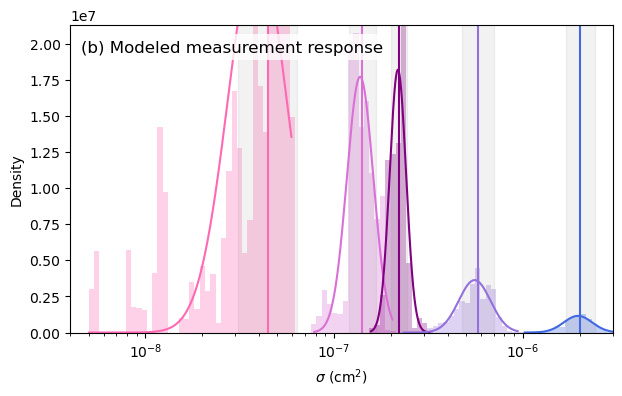

In [20]:
# plot and calculate stats for log-normal distributions
mode_scs =[]
gsd_scs = []
geom_mean_scs = []
mean_scs = []
scale_T =[]
shape_T=[]
lab = ['2','5','8','15','30']
farben = ['hotpink', 'orchid', 'purple', 'mediumpurple', 'royalblue']

fig,ax = plt.subplots(figsize=(7,4))
for i, col in enumerate(SCS.columns):
    shape, loc, scale = lognorm.fit(SCS[col], floc=0)
    
    mode_fit = scale * np.exp(-shape**2)
    mode_scs.append(mode_fit)
    
    gsd_fit  = np.exp(shape)
    gsd_scs.append(gsd_fit)
    
    geom_mean = scale
    geom_mean_scs.append(geom_mean)

    mean = scale * np.exp(shape**2 / 2)
    mean_scs.append(mean)
    
    scale_T.append(scale)
    shape_T.append(shape)

    ax.hist(SCS[col], bins=np.logspace(np.log10(0.5e-8), np.log10(3e-6), 100), density=True, color = farben[i], alpha = 0.3,)
    # PDF
    x = np.linspace(SCS[col].min(), SCS[col].max(), 1000)
    pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
    ax.plot(x, pdf, color = farben[i], label = f"{lab[i]} µm")

    ax.axvline(geom_mean, color = farben[i], label = 'geom_mean' if i == 4 else None)
    
    ax.fill_betweenx(y = ax.get_ylim(), x1 = geom_mean/gsd_fit, x2 = geom_mean*gsd_fit, color = 'grey', alpha = 0.1, label = 'GSD range' if i == 4 else None)


    # Labels
    ax.set(
        ylim=(0, ax.get_ylim()[1]*0.78),
        xlabel="$\sigma$ (cm$^2$)",
        ylabel="Density",
        xscale = 'log',
        xlim=(0.4e-8, 3e-6)
       
    )
    
ax.text(0.02, 0.95, "(b) Modeled measurement response", transform=ax.transAxes, ha='left', va='top', fontsize=12,bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
#plt.savefig("theoretical_SCS_all.png", bbox_inches='tight')
plt.show()


In [22]:
stats_scs = pd.DataFrame([mode_scs, geom_mean_scs, gsd_scs, mean_scs, scale_T, shape_T], index = ['mode','geom_mean', 'gsd', 'mean', 'scale', 'shape'], columns = dfs.keys()).T
stats_scs

,mode,geom_mean,gsd,mean,scale,shape
b2_a,3.917127e-08,4.452516e-08,1.430360,4.747057e-08,4.452516e-08,0.357926
b5,1.374259e-07,1.410688e-07,1.175564,1.429262e-07,1.410688e-07,0.161748
b8_a,2.179026e-07,2.200970e-07,1.105282,2.212025e-07,2.200970e-07,0.100100
b15_a,5.556676e-07,5.769851e-07,1.214128,5.879486e-07,5.769851e-07,0.194026
b30_a,1.961462e-06,2.021657e-06,1.189889,2.052444e-06,2.021657e-06,0.173860


In [23]:
# T = theory, M = measured
# calculate from  fits
mu_T = np.log(stats_scs['geom_mean'])  # geometric mean
sigma_T = stats_scs['shape'] # std

mu_M = np.log(stats_beads['geom_mean'])
sigma_M = stats_beads['shape']

# propagated parameters
mu_S = mu_T - mu_M 
sigma_S = np.sqrt(sigma_T**2 + sigma_M**2 - 2*sigma_T*sigma_M)

# back to linear space
scale_S = np.exp(mu_S)
gsd_S   = np.exp(sigma_S)
geom_mean_S = scale_S
mean_S = scale_S * np.exp(sigma_S**2 / 2)

mode_S = scale_S * np.exp(-sigma_S**2)

In [ ]:
# give everything the same index
mode_S.index =nominal_diameter
gsd_S.index = nominal_diameter
geom_mean_S.index = nominal_diameter
mean_S.index = nominal_diameter
measurements_described.index = nominal_diameter 
scs_described = scs_described.T
scs_described.index = nominal_diameter

/tmp/ipykernel_1717940/4235427020.py:3: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(mode_S,'-o', c = 'k', linestyle='--', label = 'mode')


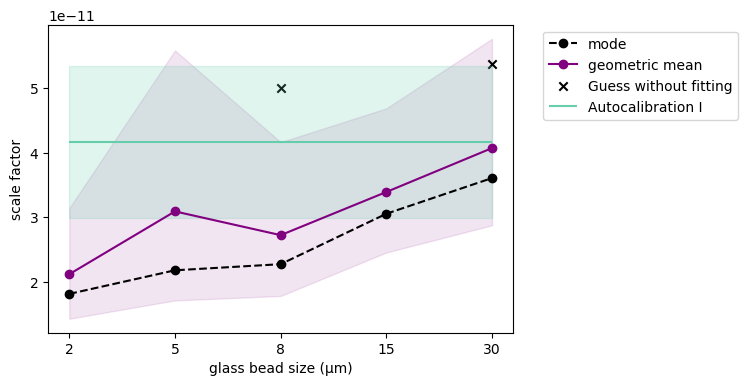

In [ ]:
# make figsize 
plt.figure(figsize=(6,4))
plt.plot(mode_S,'-o', c = 'k', linestyle='--', label = 'mode')
plt.plot(geom_mean_S, '-o',c = 'purple', label = 'geometric mean')

plt.fill_between(geom_mean_S.index, (geom_mean_S/gsd_S),( geom_mean_S*gsd_S), alpha = 0.1, color = 'purple')
plt.scatter([2,4], [1/2e10,1/1.86e10], color = 'k', marker='x', label = "Guess without fitting")
plt.hlines(y=[4.17e-11], xmin=0, xmax=4, colors='mediumaquamarine',  label = 'Autocalibration I')
plt.fill_between( x=mode_S.index, y1 = (4.17e-11-1.18e-11), y2=4.17e-11+1.18e-11,color = 'mediumaquamarine', alpha = 0.2)

plt.ylabel('scale factor')
plt.xlabel('glass bead size (µm)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.savefig("scale_factor_summary.png", bbox_inches='tight')
plt.show()

In [30]:
# get c_F for 30µm amd 15µm glass beads
geom_mean_S


2     2.118642e-11
5     3.093102e-11
8     2.724369e-11
15    3.394121e-11
30    4.075223e-11
Name: geom_mean, dtype: float64

In [ ]:
# get gsd for 30µm amd 15µm glass beads
gsd_S

2     1.484102
5     1.807315
8     1.529761
15    1.382304
30    1.416436
Name: shape, dtype: float64